In [ ]:
from datasets import load_dataset
dataset = load_dataset("databricks/databricks-dolly-15k")

In [ ]:
import pandas as pd

df = dataset["train"].to_pandas()

df.head()

,instruction,context,response,category
0,When did Virgin Australia start operating?,"Virgin Australia, the trading name of Virgin A...",Virgin Australia commenced services on 31 Augu...,closed_qa
1,Which is a species of fish? Tope or Rope,,Tope,classification
2,Why can camels survive for long without water?,,Camels use the fat in their humps to keep them...,open_qa
3,"Alice's parents have three daughters: Amy, Jes...",,The name of the third daughter is Alice,open_qa
4,When was Tomoaki Komorida born?,Komorida was born in Kumamoto Prefecture on Ju...,"Tomoaki Komorida was born on July 10,1981.",closed_qa


In [ ]:
df["category"].value_counts()

,count
category,
open_qa,3742
general_qa,2191
classification,2136
closed_qa,1773
brainstorming,1766
information_extraction,1506
summarization,1188
creative_writing,709


In [ ]:
df = df[df["category"].isin(["open_qa", "general_qa", "classification", "closed_qa"])]
df["category"].value_counts()

,count
category,
open_qa,3742
general_qa,2191
classification,2136
closed_qa,1773


In [ ]:
def create_balanced_dataset(df):

    # Count the instances of "spam"
    num_spam = df[df["category"] == "closed_qa"].shape[0]

    # Randomly sample "ham" instances to match the number of 0 instances
    label1_subset = df[df["category"] == "general_qa"].sample(num_spam, random_state=123)
    label2_subset = df[df["category"] == "classification"].sample(num_spam, random_state=123)
    # label3_subset = df[df["category"] == "open_qa"].sample(num_spam, random_state=123)

    # Combine ham "subset" with 0
    balanced_df = pd.concat([label1_subset, label2_subset, df[df["category"] == "closed_qa"]])

    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["category"].value_counts())

category
general_qa        1773
classification    1773
closed_qa         1773
Name: count, dtype: int64


In [ ]:
data = []

for index, row in balanced_df.iterrows():
    data.append({
        "Instruction": row["instruction"],
        "Input": row["context"],
        "Output": row["response"]
    })

data[50]

{'Instruction': 'What are Jindo dogs like?',
 'Input': '',
 'Output': 'Jindos are extremely loyal, and territorial. Unlike most dogs, Jindos do not play fetch, and rarely bark. They are also very independent, and some would say they march to the beat of their own drum. When meeting strangers they tend to be very reserved, but are highly affectionate to their owners. It is very hard to earn their trust, but once you do Jindos make loving companions.'}

In [ ]:
def format_input(entry):
    instruction_text = (
        f"Below is an instruction that describes a task. "
        f"Write a response that appropriately completes the request."
        f"\n\n### Instruction:\n{entry['Instruction']}"
    )

    input_text = f"\n\n### Input:\n{entry['Input']}" if entry["Input"] else ""

    return instruction_text + input_text

In [ ]:
model_input = format_input(data[50])
desired_response = f"\n\n### Response:\n{data[50]['Output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
What are Jindo dogs like?

### Response:
Jindos are extremely loyal, and territorial. Unlike most dogs, Jindos do not play fetch, and rarely bark. They are also very independent, and some would say they march to the beat of their own drum. When meeting strangers they tend to be very reserved, but are highly affectionate to their owners. It is very hard to earn their trust, but once you do Jindos make loving companions.


In [ ]:
model_input = format_input(data[999])
desired_response = f"\n\n### Response:\n{data[999]['Output']}"

print(model_input + desired_response)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Who is the founder of SpaceX?

### Response:
SpaceX, also known as Space Exploration Technologies Corporation, was founded by Elon Musk in 2003 in Segundo California.


In [ ]:
len(data)

5319

In [ ]:
train_portion = int(len(data) * 0.85)  # 85% for training
test_portion = int(len(data) * 0.1)    # 10% for testing
val_portion = len(data) - train_portion - test_portion  # Remaining 5% for validation

train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]

In [ ]:
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))

Training set length: 4521
Validation set length: 267
Test set length: 531


In [ ]:
import torch
from torch.utils.data import Dataset


class InstructionDataset(Dataset):
    def __init__(self, data, tokenizer):
        self.data = data

        # Pre-tokenize texts
        self.encoded_texts = []
        for entry in data:
            instruction_plus_input = format_input(entry)
            response_text = f"\n\n### Response:\n{entry['Output']}"
            full_text = instruction_plus_input + response_text
            self.encoded_texts.append(
                tokenizer.encode(full_text)
            )

    def __getitem__(self, index):
        return self.encoded_texts[index]

    def __len__(self):
        return len(self.data)

In [ ]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [ ]:
def custom_collate_draft_1(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_lst = []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        # this always adds at least 1 additional padding tokens
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        # We remove this extra padded token again here
        inputs = torch.tensor(padded[:-1])
        inputs_lst.append(inputs)

    # Convert list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    return inputs_tensor

In [ ]:
def custom_collate_draft_2(
    batch,
    pad_token_id=50256,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets
        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs to tensor and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)
    return inputs_tensor, targets_tensor

In [ ]:
def custom_collate_fn(
    batch,
    pad_token_id=50256,
    ignore_index=-100,
    allowed_max_length=712,
    device="cpu"
):
    # Find the longest sequence in the batch
    batch_max_length = max(len(item)+1 for item in batch)

    # Pad and prepare inputs and targets
    inputs_lst, targets_lst = [], []

    for item in batch:
        new_item = item.copy()
        # Add an <|endoftext|> token
        new_item += [pad_token_id]
        # Pad sequences to max_length
        padded = new_item + [pad_token_id] * (batch_max_length - len(new_item))
        inputs = torch.tensor(padded[:-1])  # Truncate the last token for inputs
        targets = torch.tensor(padded[1:])  # Shift +1 to the right for targets

        # New: Replace all but the first padding tokens in targets by ignore_index
        mask = targets == pad_token_id
        indices = torch.nonzero(mask).squeeze()
        if indices.numel() > 1:
            targets[indices[1:]] = ignore_index

        # New: Optionally truncate to maximum sequence length
        if allowed_max_length is not None:
            inputs = inputs[:allowed_max_length]
            targets = targets[:allowed_max_length]

        inputs_lst.append(inputs)
        targets_lst.append(targets)

    # Convert list of inputs and targets to tensors and transfer to target device
    inputs_tensor = torch.stack(inputs_lst).to(device)
    targets_tensor = torch.stack(targets_lst).to(device)

    return inputs_tensor, targets_tensor

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# If you have a Mac with Apple Silicon chip, you can uncomment the next lines of code
# to train the model on the Mac's GPU cores. However, as of this writing, this results in
# larger numerical deviations from the results shown in this chapter, because Apple Silicon
# support in PyTorch is still experimental

# if torch.backends.mps.is_available():
#     device = torch.device("mps")

print("Device:", device)

Device: cuda


In [ ]:
from functools import partial

customized_collate_fn = partial(custom_collate_fn, device=device, allowed_max_length=1024)

In [ ]:
from torch.utils.data import DataLoader


num_workers = 0
batch_size = 1

torch.manual_seed(123)

train_dataset = InstructionDataset(train_data, tokenizer)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=True,
    drop_last=True,
    num_workers=num_workers
)

In [ ]:
train_batch = next(iter(train_loader))
print(train_batch[0].shape)
print(train_batch[1].shape)

torch.Size([1, 475])
torch.Size([1, 475])


In [ ]:
print("Train loader:")
for inputs, targets in train_loader:
    print(inputs.shape, targets.shape)

Train loader:
torch.Size([1, 86]) torch.Size([1, 86])
torch.Size([1, 116]) torch.Size([1, 116])
torch.Size([1, 212]) torch.Size([1, 212])
torch.Size([1, 78]) torch.Size([1, 78])
torch.Size([1, 92]) torch.Size([1, 92])
torch.Size([1, 52]) torch.Size([1, 52])
torch.Size([1, 70]) torch.Size([1, 70])
torch.Size([1, 73]) torch.Size([1, 73])
torch.Size([1, 123]) torch.Size([1, 123])
torch.Size([1, 90]) torch.Size([1, 90])
torch.Size([1, 89]) torch.Size([1, 89])
torch.Size([1, 90]) torch.Size([1, 90])
torch.Size([1, 75]) torch.Size([1, 75])
torch.Size([1, 121]) torch.Size([1, 121])
torch.Size([1, 115]) torch.Size([1, 115])
torch.Size([1, 50]) torch.Size([1, 50])
torch.Size([1, 378]) torch.Size([1, 378])
torch.Size([1, 60]) torch.Size([1, 60])
torch.Size([1, 85]) torch.Size([1, 85])
torch.Size([1, 80]) torch.Size([1, 80])
torch.Size([1, 172]) torch.Size([1, 172])
torch.Size([1, 159]) torch.Size([1, 159])
torch.Size([1, 74]) torch.Size([1, 74])
torch.Size([1, 52]) torch.Size([1, 52])
torch.Size

In [ ]:
val_dataset = InstructionDataset(val_data, tokenizer)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

test_dataset = InstructionDataset(test_data, tokenizer)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    collate_fn=customized_collate_fn,
    shuffle=False,
    drop_last=False,
    num_workers=num_workers
)

In [ ]:
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt


BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

CHOOSE_MODEL = "gpt2-medium (355M)"

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
model.eval();

File already exists and is up-to-date: gpt2/355M/checkpoint
File already exists and is up-to-date: gpt2/355M/encoder.json
File already exists and is up-to-date: gpt2/355M/hparams.json
File already exists and is up-to-date: gpt2/355M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/355M/model.ckpt.index
File already exists and is up-to-date: gpt2/355M/model.ckpt.meta
File already exists and is up-to-date: gpt2/355M/vocab.bpe


In [ ]:
torch.manual_seed(123)

input_text = format_input(val_data[0])
print(input_text)

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Where was Sarah Schechter born?

### Input:
Schechter was born in Boston and grew up in Brookline, Massachusetts and New York City. Her father, Danny Schechter, a grandson of Russian-Jewish immigrant socialists, was a human rights activist, author, filmmaker and television producer.


In [ ]:
# from previous_chapters import (
#     generate,
#     text_to_token_ids,
#     token_ids_to_text
# )

# token_ids = generate(
#     model=model,
#     idx=text_to_token_ids(input_text, tokenizer),
#     max_new_tokens=35,
#     context_size=BASE_CONFIG["context_length"],
#     eos_id=50256,
# )
# generated_text = token_ids_to_text(token_ids, tokenizer)

In [ ]:
# response_text = generated_text[len(input_text):].strip()
# print(response_text)

In [ ]:
from previous_chapters import (
    calc_loss_loader,
    train_model_simple
)

In [ ]:
model.to(device)

torch.manual_seed(123)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 3.176259899139404
Validation loss: 2.749566602706909


In [ ]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.000075, weight_decay=0.075)

num_epochs = 2

train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context=format_input(val_data[0]), tokenizer=tokenizer
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.917, Val loss 2.413
Ep 1 (Step 000005): Train loss 1.655, Val loss 1.973
Ep 1 (Step 000010): Train loss 2.127, Val loss 1.932
Ep 1 (Step 000015): Train loss 2.323, Val loss 1.923
Ep 1 (Step 000020): Train loss 1.972, Val loss 1.873
Ep 1 (Step 000025): Train loss 1.785, Val loss 1.870
Ep 1 (Step 000030): Train loss 1.997, Val loss 1.873
Ep 1 (Step 000035): Train loss 1.450, Val loss 1.858
Ep 1 (Step 000040): Train loss 1.653, Val loss 1.854
Ep 1 (Step 000045): Train loss 1.960, Val loss 1.844
Ep 1 (Step 000050): Train loss 2.349, Val loss 1.837
Ep 1 (Step 000055): Train loss 1.919, Val loss 1.829
Ep 1 (Step 000060): Train loss 2.020, Val loss 1.836
Ep 1 (Step 000065): Train loss 1.591, Val loss 1.854
Ep 1 (Step 000070): Train loss 1.318, Val loss 1.855
Ep 1 (Step 000075): Train loss 1.842, Val loss 1.852
Ep 1 (Step 000080): Train loss 1.797, Val loss 1.847
Ep 1 (Step 000085): Train loss 2.148, Val loss 1.854
Ep 1 (Step 000090): Train loss 1.952, Val loss

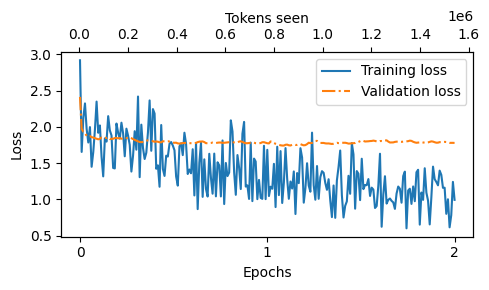

In [ ]:
from previous_chapters import plot_losses

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

In [ ]:
from previous_chapters import (
    generate,
    text_to_token_ids,
    token_ids_to_text
)


torch.manual_seed(123)


for entry in test_data[:3]:

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

    print(input_text)
    print(f"\nCorrect response:\n>> {entry['Output']}")
    print(f"\nModel response:\n>> {response_text.strip()}")
    print("-------------------------------------")

Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
According to this paragraph, what was the most common type of castle in England following the Norman Conquest?

### Input:
There are nine castles in Greater Manchester, a metropolitan county in North West England. They consist of four motte-and-bailey castles, three fortified manor houses, an enclosure castle, and a possible shell keep. A motte-and-bailey castle is characterised by two elements: the motte is an artificial mound with a wooden stockade and stronghold on top, usually a stone keep or tower, while the bailey is a defended enclosure adjacent to the motte, typically enclosed by a ditch and a bank topped by a timber palisade or stone wall. Motte-and-bailey castles were the most common type of castle in England following the Norman Conquest. A shell keep was a motte with a stone wall rather than a wooden stockade on top; there would have been no tower with

In [ ]:
from tqdm import tqdm
import json
for i, entry in tqdm(enumerate(test_data), total=len(test_data)):

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

    test_data[i]["model_response"] = response_text


with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)  # "indent" for pretty-printing

 10%|▉         | 52/531 [09:03<38:20,  4.80s/it]

In [ ]:
import torch

def generate_response_advanced(
    model, tokenizer, device, prompt,
    max_new_tokens=100,
    temperature=0.7,
    top_k=40,
    repetition_penalty=1.3
):
    model.eval()
    eos_id = tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"})[0]
    encoded = tokenizer.encode(prompt)
    input_tensor = torch.tensor(encoded, device=device).unsqueeze(0)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            idx_cond = input_tensor[:, -model.pos_emb.weight.shape[0]:]
            logits = model(idx_cond)[:, -1, :]

            # ۱. اعمال جریمه تکرار (Repetition Penalty) برای شکستن لوپ‌های نمونه ۳
            for token_id in set(input_tensor[0].tolist()):
                if logits[0, token_id] > 0:
                    logits[0, token_id] /= repetition_penalty
                else:
                    logits[0, token_id] *= repetition_penalty

            # ۲. اعمال Temperature برای تنظیم قطعیت مدل
            logits = logits / max(temperature, 1e-5)

            # ۳. اعمال Top-k Sampling به جای انتخاب قطعی (Greedy)
            if top_k is not None:
                top_logits, _ = torch.topk(logits, top_k)
                min_val = top_logits[:, -1]
                logits = torch.where(logits < min_val, torch.tensor(float('-inf'), device=device), logits)

            # محاسبه احتمالات و سمپلینگ
            probs = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)

            # توقف فوری با دیدن توکن پایان
            if next_token.item() == eos_id:
                break

            input_tensor = torch.cat((input_tensor, next_token), dim=1)

    decoded = tokenizer.decode(input_tensor.squeeze(0).tolist())
    if "### Response:" in decoded:
        return decoded.split("### Response:")[-1].strip()
    return decoded

In [ ]:
from tqdm import tqdm
import json

for i, entry in tqdm(enumerate(test_data), total=len(test_data)):

    input_text = format_input(entry)

    token_ids = generate(
        model=model,
        idx=text_to_token_ids(input_text, tokenizer).to(device),
        max_new_tokens=256,
        context_size=BASE_CONFIG["context_length"],
        eos_id=50256
    )
    generated_text = token_ids_to_text(token_ids, tokenizer)
    response_text = generated_text[len(input_text):].replace("### Response:", "").strip()

    test_data[i]["model_response"] = response_text


with open("instruction-data-with-response.json", "w") as file:
    json.dump(test_data, file, indent=4)  # "indent" for pretty-printing